In [3]:
import numpy as np
import tensorflow as tf
# from keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

LOADING MODEL

In [4]:
model = tf.keras.models.load_model('trained_model.keras')

/Users/ajayyadav/Downloads/eAgro/eAgro/lib/python3.10/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 26 variables whereas the saved optimizer has 50 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [3]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 256, 256, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 254, 254, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 127, 127, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 125, 125, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 62, 62, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 60, 60, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 30, 30, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 28, 28, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 14, 14, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 12, 12, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 6, 6, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 6, 6, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1500)           │    27,649,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1500)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 13)             │        19,513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 64,762,476 (247.05 MB)

 Trainable params: 32,381,237 (123.52 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 32,381,239 (123.52 MB)

VISULAISING SINGLE IMAGE OF TEST SET

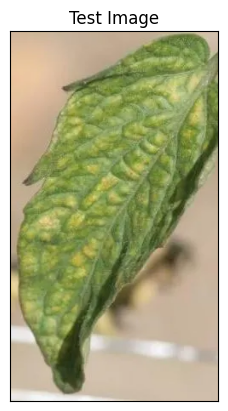

In [41]:
import cv2
image_path = '/Users/ajayyadav/Downloads/eAgro/captured_images/Spidemist.jpg'

img = cv2.imread(image_path)
img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.title('Test Image')
plt.xticks([])
plt.yticks([])
plt.show()

TESTING MODEL

In [42]:
image = tf.keras.preprocessing.image.load_img(image_path,target_size=(256,256))
input_arr = tf.keras.preprocessing.image.img_to_array(image)
input_arr = np.array([input_arr])
print(input_arr.shape)

(1, 256, 256, 3)


In [43]:
prediction = model.predict([input_arr])
prediction,prediction.shape

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step


(array([[4.9213737e-05, 5.1793344e-03, 7.5257309e-02, 1.7092815e-04,
         1.0523450e-03, 1.4802685e-01, 4.2583209e-02, 6.9112283e-01,
         7.0508941e-05, 9.4141418e-05, 3.6330234e-02, 2.0609230e-05,
         4.2424410e-05]], dtype=float32),
 (1, 13))

In [44]:
result_index = np.argmax(prediction)
result_index

np.int64(7)

In [45]:
class_name = ['Potato___Early_blight',
 'Potato___Late_blight',
 'Potato___healthy',
 'Tomato___Bacterial_spot',
 'Tomato___Early_blight',
 'Tomato___Late_blight',
 'Tomato___Leaf_Mold',
 'Tomato___Septoria_leaf_spot',
 'Tomato___Spider_mites Two-spotted_spider_mite',
 'Tomato___Target_Spot',
 'Tomato___Tomato_Yellow_Leaf_Curl_Virus',
 'Tomato___Tomato_mosaic_virus',
 'Tomato___healthy']

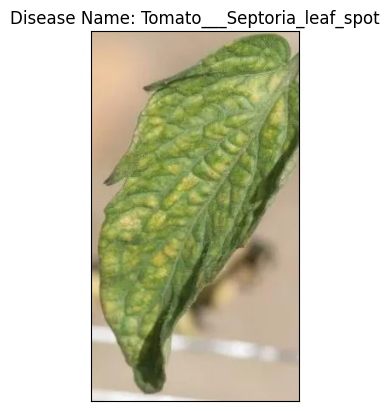

In [46]:
model_prediction = class_name[result_index]
plt.imshow(img)
plt.title(f'Disease Name: {model_prediction}')
plt.xticks([])
plt.yticks([])
plt.show()

In [1]:
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# Load your trained model
model = tf.keras.models.load_model("trained_model.keras")

# Image path
image_path = '/Users/ajayyadav/Downloads/eAgro/Dataset/test/TomatoYellowCurlVirus3.JPG'

# Preprocess image
img = tf.keras.preprocessing.image.load_img(image_path, target_size=(256,256))
img_array = tf.keras.preprocessing.image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0) / 255.0

# -----------------------------
# Create a new model to extract intermediate outputs
# -----------------------------
layer_outputs = [layer.output for layer in model.layers if 'conv' in layer.name]

feature_map_model = tf.keras.models.Model(inputs=model.input, outputs=layer_outputs)

# Get feature maps
feature_maps = feature_map_model.predict(img_array)

# -----------------------------
# Plot feature maps
# -----------------------------
for layer_index, fmap in enumerate(feature_maps):
    print(f"Showing feature maps from layer {layer_index}")

    # Take only first image in batch
    fmap = fmap[0]

    # Number of feature maps to display
    num_filters = min(fmap.shape[-1], 16)

    plt.figure(figsize=(12, 8))

    for i in range(num_filters):
        plt.subplot(4, 4, i+1)
        plt.imshow(fmap[:, :, i], cmap='viridis')
        plt.axis('off')

    plt.suptitle(f"Layer {layer_index} Feature Maps")
    plt.show()

/Users/ajayyadav/Downloads/eAgro/eAgro/lib/python3.10/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 26 variables whereas the saved optimizer has 50 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


AttributeError: The layer sequential_1 has never been called and thus has no defined input.